# Proyecto: Minería de Datos - Sistemas de Recomendación con MovieLens 20M
## Minería de Patrones y Similitud con Spark, MinHashing y LSH

---

## SETUP INICIAL: Configuración de Spark y Importaciones

### Paso 1: Configurar la sesión de Spark


In [1]:
import sys
!{sys.executable} -m pip install pyspark

# Importaciones de Spark
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.ml.feature import MinHashLSH
from pyspark.ml.linalg import Vectors

# Importaciones cientificas y visualizacion
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import time

# Importaciones GPU (RAPIDS)
try:
    import cudf
    import cuml
    GPU_AVAILABLE = True
    print("✓ cuDF y cuML detectados - GPU acceleration habilitado")
except ImportError:
    GPU_AVAILABLE = False
    print("⚠ cuDF/cuML no disponibles - usando CPU solamente")

# Configuracion visual
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

# =====================================================
# PERFIL DE EJECUCION: quick | full
# Cambia RUN_PROFILE a "quick" si quieres iterar mas rapido
# =====================================================
RUN_PROFILE = "full"

# =====================================================
# ESTRATEGIA: CPU (Spark) + GPU (cuDF/cuML) - HIBRIDA
# Spark maneja I/O y preprocesamiento CPU
# cuDF/cuML aceleran operaciones de ML en GPU cuando estan disponibles
# =====================================================
EXEC_MODE = "HYBRID"  # Spark CPU + GPU para ML
GPU_ENABLED = GPU_AVAILABLE

# =====================================================
# CONFIGURACION DEL DATASET: 30% DE MUESTREO
# =====================================================
DATASET_SAMPLING_PERCENT = 0.30  # Usar 30% del dataset total

PROFILE_SETTINGS = {
    "quick": {
        "spark": {
            "driver_memory": "4g",
            "executor_memory": "4g",
            "shuffle_partitions": "120",
            "default_parallelism": "120"
        },
        "sample_size": 0.10,
        "num_hash_functions": 400,
        "lsh_configurations": [(50, 8), (80, 5), (100, 4), (200, 2)],
        "lsh_real_threshold": 0.85,
        "spark_lsh_num_hash_tables": 48,
        "spark_distance_threshold": 0.35
    },
    "full": {
        "spark": {
            "driver_memory": "8g",
            "executor_memory": "8g",
            "shuffle_partitions": "400",
            "default_parallelism": "400"
        },
        "sample_size": 0.10,
        "num_hash_functions": 1200,
        "lsh_configurations": [(120, 10), (150, 8), (240, 5), (300, 4), (600, 2)],
        "lsh_real_threshold": 0.85,
        "spark_lsh_num_hash_tables": 96,
        "spark_distance_threshold": 0.30
    }
}

if RUN_PROFILE not in PROFILE_SETTINGS:
    raise ValueError("RUN_PROFILE debe ser 'quick' o 'full'")

settings = PROFILE_SETTINGS[RUN_PROFILE]
spark_cfg = settings["spark"]
SAMPLE_SIZE_SETTING = settings["sample_size"]

# Si ya existe una sesion, la cerramos para aplicar nueva configuracion
if "spark" in globals():
    try:
        spark.stop()
    except Exception:
        pass

# Inicializar sesion de Spark (SOLO CPU, sin plugin RAPIDS)
spark = SparkSession.builder \
    .appName(f"MovieLens-20M-MinHash-LSH-{RUN_PROFILE}-HYBRID") \
    .config("spark.driver.memory", spark_cfg["driver_memory"]) \
    .config("spark.executor.memory", spark_cfg["executor_memory"]) \
    .config("spark.sql.shuffle.partitions", spark_cfg["shuffle_partitions"]) \
    .config("spark.default.parallelism", spark_cfg["default_parallelism"]) \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

# Configurar nivel de log
spark.sparkContext.setLogLevel("WARN")

# Parametros globales reutilizados en las secciones pesadas
SAMPLE_SIZE = settings["sample_size"]
NUM_HASH_FUNCTIONS = settings["num_hash_functions"]
LSH_CONFIGURATIONS = settings["lsh_configurations"]
LSH_REAL_THRESHOLD = settings["lsh_real_threshold"]
SPARK_LSH_NUM_HASH_TABLES = settings["spark_lsh_num_hash_tables"]
SPARK_APPROX_DISTANCE_THRESHOLD = settings["spark_distance_threshold"]

print("✓ Spark sesion inicializada correctamente")
print(f"✓ Spark version: {spark.version}")
print(f"✓ Perfil activo: {RUN_PROFILE}")
print(f"✓ Modo de ejecucion: {EXEC_MODE}")
print(f"✓ GPU acceleration (cuDF/cuML): {'HABILITADO' if GPU_ENABLED else 'DESHABILITADO'}")
print(f"✓ Spark driver/executor: {spark_cfg['driver_memory']} / {spark_cfg['executor_memory']}")
print(f"✓ Dataset sampling: {DATASET_SAMPLING_PERCENT*100:.0f}%")
if isinstance(SAMPLE_SIZE_SETTING, float) and SAMPLE_SIZE_SETTING <= 1:
    print(f"✓ sample_size configurado: {SAMPLE_SIZE_SETTING*100:.0f}% del total")
elif isinstance(SAMPLE_SIZE_SETTING, int):
    print(f"✓ sample_size configurado: {SAMPLE_SIZE_SETTING}")
else:
    print(f"✓ sample_size configurado: {SAMPLE_SIZE_SETTING}")
print(f"✓ num_hash_functions={NUM_HASH_FUNCTIONS}")
print(f"✓ spark_lsh_num_hash_tables={SPARK_LSH_NUM_HASH_TABLES}, dist_threshold={SPARK_APPROX_DISTANCE_THRESHOLD}")

if GPU_ENABLED:
    print("\n📊 GPU Setup:")
    print(f"   cuDF version: {cudf.__version__}")
    print(f"   cuML version: {cuml.__version__}")
    print("   GPU acceleration lista para operaciones de ML")


⚠ cuDF/cuML no disponibles - usando CPU solamente
✓ Spark sesion inicializada correctamente
✓ Spark version: 4.0.2
✓ Perfil activo: full
✓ Modo de ejecucion: HYBRID
✓ GPU acceleration (cuDF/cuML): DESHABILITADO
✓ Spark driver/executor: 8g / 8g
✓ Dataset sampling: 30%
✓ sample_size configurado: 10% del total
✓ num_hash_functions=1200
✓ spark_lsh_num_hash_tables=96, dist_threshold=0.3


### Paso 2: Cargar los datos del dataset MovieLens 20M

Cargaremos los archivos CSV principales en DataFrames de Spark para procesarlos de manera distribuida:
- **ratings.csv:** Contiene todas las calificaciones
- **movies.csv:** Información sobre películas y géneros
- **tags.csv:** Tags asignados por usuarios

In [2]:
# Definir ruta base del dataset
dataset_path = "/content/"

# Definir esquema explicito para evitar inferencias incorrectas
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, FloatType, LongType

ratings_schema = StructType([
    StructField("userId", IntegerType(), False),
    StructField("movieId", IntegerType(), False),
    StructField("rating", FloatType(), False),
    StructField("timestamp", LongType(), False)
])

movies_schema = StructType([
    StructField("movieId", IntegerType(), False),
    StructField("title", StringType(), False),
    StructField("genres", StringType(), False)
])

tags_schema = StructType([
    StructField("userId", IntegerType(), False),
    StructField("movieId", IntegerType(), False),
    StructField("tag", StringType(), False),
    StructField("timestamp", LongType(), False)
])

# Cargar ratings.csv
print("Cargando ratings.csv...")
ratings = spark.read.csv(
    f"{dataset_path}/ratings.csv",
    header=True,
    schema=ratings_schema
)
print(f"✓ Ratings cargadas: {ratings.count()} registros")
ratings.printSchema()

print("\n" + "=" * 80 + "\n")

# Cargar movies.csv
print("Cargando movies.csv...")
movies = spark.read.csv(
    f"{dataset_path}/movies.csv",
    header=True,
    schema=movies_schema
)
print(f"✓ Movies cargadas: {movies.count()} peliculas")
movies.printSchema()

print("\n" + "=" * 80 + "\n")

# Cargar tags.csv
print("Cargando tags.csv...")
tags = spark.read.csv(
    f"{dataset_path}/tags.csv",
    header=True,
    schema=tags_schema
)
print(f"✓ Tags cargados: {tags.count()} registros")
tags.printSchema()

print("\n✓ Todos los archivos cargados correctamente")

Cargando ratings.csv...
✓ Ratings cargadas: 9287278 registros
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: float (nullable = true)
 |-- timestamp: long (nullable = true)



Cargando movies.csv...
✓ Movies cargadas: 27278 peliculas
root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)



Cargando tags.csv...
✓ Tags cargados: 465564 registros
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- tag: string (nullable = true)
 |-- timestamp: long (nullable = true)


✓ Todos los archivos cargados correctamente


In [3]:
ratings.printSchema()

root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: float (nullable = true)
 |-- timestamp: long (nullable = true)



---

# PARTE I: PREPROCESAMIENTO Y EXPLORACIÓN DE DATOS (EDA)

## Introducción a la Parte I

En esta sección realizaremos:
1. **Limpieza y preprocesamiento:** Eliminar nulos, inconsistencias y duplicados
2. **Normalización:** Unificar etiquetas de géneros
3. **Transformación:** Convertir ratings a escala binaria (like/dislike)
4. **Exploración:** Análisis estadístico y visualización del dataset

Estas operaciones se ejecutarán con **Spark SQL y DataFrames** para aprovechar el procesamiento distribuido en el dataset completo.

---

## 1.1 PREPROCESAMIENTO

### Paso 1: Detectar y manejar valores nulos

In [4]:
# Detectar valores nulos en cada dataset
print("ANÁLISIS DE VALORES NULOS\n")

# Usar solo isNull() para evitar problemas con tipo casting en isnan()
print("Ratings:")
ratings.select([count(when(col(c).isNull(), c)).alias(c) for c in ratings.columns]).show()

print("\nMovies:")
movies.select([count(when(col(c).isNull(), c)).alias(c) for c in movies.columns]).show()

print("\nTags:")
tags.select([count(when(col(c).isNull(), c)).alias(c) for c in tags.columns]).show()

# Eliminar registros con valores nulos
ratings_clean = ratings.dropna()
movies_clean = movies.dropna()
tags_clean = tags.dropna()

print("\n" + "="*80)
print("Después de eliminar nulos:")
print(f"Ratings: {ratings.count()} → {ratings_clean.count()}")
print(f"Movies: {movies.count()} → {movies_clean.count()}")
print(f"Tags: {tags.count()} → {tags_clean.count()}")

ANÁLISIS DE VALORES NULOS

Ratings:
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     0|      0|     0|        0|
+------+-------+------+---------+


Movies:
+-------+-----+------+
|movieId|title|genres|
+-------+-----+------+
|      0|    0|     0|
+-------+-----+------+


Tags:
+------+-------+---+---------+
|userId|movieId|tag|timestamp|
+------+-------+---+---------+
|     0|      0|  0|        0|
+------+-------+---+---------+


Después de eliminar nulos:
Ratings: 9287278 → 9287278
Movies: 27278 → 27278
Tags: 465564 → 465564


### Paso 2: Eliminar duplicados

In [5]:
# Detectar duplicados en ratings
# Un duplicado sería el mismo usuario calificando la misma película más de una vez
print("ANÁLISIS DE DUPLICADOS\n")

print(f"Ratings antes de remover duplicados: {ratings_clean.count()}")
ratings_dedupe = ratings_clean.dropDuplicates(["userId", "movieId"])
print(f"Ratings después de remover duplicados: {ratings_dedupe.count()}")

print(f"\nMovies antes de remover duplicados: {movies_clean.count()}")
movies_dedupe = movies_clean.dropDuplicates(["movieId"])
print(f"Movies después de remover duplicados: {movies_dedupe.count()}")

print(f"\nTags antes de remover duplicados: {tags_clean.count()}")
tags_dedupe = tags_clean.dropDuplicates(["userId", "movieId", "tag"])
print(f"Tags después de remover duplicados: {tags_dedupe.count()}")

ANÁLISIS DE DUPLICADOS

Ratings antes de remover duplicados: 9287278
Ratings después de remover duplicados: 9287278

Movies antes de remover duplicados: 27278
Movies después de remover duplicados: 27278

Tags antes de remover duplicados: 465564
Tags después de remover duplicados: 465564


### Paso 3: Transformar ratings a escala binaria

**Justificación de la escala binaria:**
- Las similitudes de Jaccard y MinHashing funcionan mejor con conjuntos binarios
- Un threshold de 3.5 estrella es un punto de corte razonable: separa "películas bien calificadas" de las mediocres
- Facilita la interpretación: una película es "liked" (≥3.5) o "disliked" (<3.5)

In [6]:
# Definir umbral para escala binaria
RATING_THRESHOLD = 3.5

# Transformar ratings a escala binaria (1 = like, 0 = dislike)
ratings_binary = ratings_dedupe.withColumn(
    "binary_rating",
    when(col("rating") >= RATING_THRESHOLD, 1).otherwise(0)
).select("userId", "movieId", "rating", "binary_rating", "timestamp")

print(f"DISTRIBUCIÓN DE RATINGS BINARIOS (threshold = {RATING_THRESHOLD}):\n")
ratings_binary.groupBy("binary_rating").count().show()

# Estadísticas de la conversión
total_ratings = ratings_binary.count()
likes = ratings_binary.filter(col("binary_rating") == 1).count()
dislikes = total_ratings - likes

print(f"\nTotal de ratings: {total_ratings}")
print(f"Likes (rating >= {RATING_THRESHOLD}): {likes} ({100*likes/total_ratings:.2f}%)")
print(f"Dislikes (rating < {RATING_THRESHOLD}): {dislikes} ({100*dislikes/total_ratings:.2f}%)")

# Mostrar ejemplo de transformación
print("\nEJEMPLO DE TRANSFORMACIÓN:")
ratings_binary.limit(5).show()

DISTRIBUCIÓN DE RATINGS BINARIOS (threshold = 3.5):

+-------------+-------+
|binary_rating|  count|
+-------------+-------+
|            0|3620417|
|            1|5666861|
+-------------+-------+


Total de ratings: 9287278
Likes (rating >= 3.5): 5666861 (61.02%)
Dislikes (rating < 3.5): 3620417 (38.98%)

EJEMPLO DE TRANSFORMACIÓN:
+------+-------+------+-------------+----------+
|userId|movieId|rating|binary_rating| timestamp|
+------+-------+------+-------------+----------+
|     1|   1208|   3.5|            1|1112484815|
|     1|   1348|   3.5|            1|1094786056|
|     5|   1080|   5.0|            1| 851617674|
|     7|   1101|   3.0|            0|1011208112|
|     7|   2363|   3.0|            0|1011206779|
+------+-------+------+-------------+----------+



### Paso 4: Normalizar géneros

**Justificación:**
- MovieLens contiene variaciones inconsistentes en géneros (e.g., "Sci-Fi" vs "Science Fiction", mayúsculas inconsistentes)
- La normalización asegura que análisis posteriores agrupen correctamente películas del mismo género
- Eliminamos géneros especiales (IMAX, no-genres) que no representan géneros reales


In [7]:
#!pip install nltk

In [8]:
from pyspark.sql.functions import explode, split, col
movies.select(explode(split(col("genres"), "\\|")).alias("genre")).distinct().show()
#20 géneros


+------------------+
|             genre|
+------------------+
|             Crime|
|             Drama|
|       Documentary|
|           Mystery|
|         Film-Noir|
|(no genres listed)|
|              IMAX|
|            Horror|
|            Comedy|
|          Children|
|            Action|
|           Romance|
|          Thriller|
|         Adventure|
|               War|
|           Fantasy|
|           Musical|
|         Animation|
|           Western|
|            Sci-Fi|
+------------------+



In [9]:
# =====================================================
# NORMALIZACIÓN DE GÉNEROS MEJORADA CON SNOWBALL STEMMER
# =====================================================

print("NORMALIZACIÓN DE GÉNEROS (Snowball Stemmer + Frecuencia)\n")
print("=" * 80)

# Importaciones necesarias
import string
import nltk
from nltk.stem.snowball import SnowballStemmer
from pyspark.sql.functions import *
from pyspark.sql.types import StringType
from pyspark.sql import SparkSession
from collections import Counter

# Descargar recursos NLTK si es necesario
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

# Stemmer mejorado para inglés (mejor que Porter para variantes)
stemmer = SnowballStemmer("english")

def get_genre_stem_key(genre):
    """Extrae stem key robusto: elimina puntuación, stemming por palabra"""
    if not genre or genre.strip() == "(no genres listed)":
        return "unknown"

    # Limpiar: minúsculas, remover TODA puntuación (incluye - de sci-fi)
    clean_genre = genre.strip().lower().translate(str.maketrans('', '', string.punctuation))
    clean_genre = clean_genre.replace("_", " ")

    # Stem cada palabra
    words = clean_genre.split()
    stems = [stemmer.stem(word) for word in words if word]  # Ignorar palabras vacías

    return " ".join(stems)

# Crear mapeo stem → género MÁS FRECUENTE (no más largo)
print("Creando mapeo automático por frecuencia...\n")

# Obtener géneros únicos (asumiendo movies_dedupe existe con columna 'genres')
all_genres_raw = movies_dedupe.select(
    explode(split(col("genres"), "\\|")).alias("genre")
).select("genre").distinct().collect()

# Diccionario para contar ocurrencias por stem
stem_to_genres_count = {}
for row in all_genres_raw:
    genre = row['genre']
    stem_key = get_genre_stem_key(genre)

    if stem_key not in stem_to_genres_count:
        stem_to_genres_count[stem_key] = Counter()
    stem_to_genres_count[stem_key][genre] += 1

# Crear mapeo: cada género → su canónico (el más frecuente en su grupo)
genre_mapping = {}
for stem_key, genre_counter in stem_to_genres_count.items():
    canonical_genre = genre_counter.most_common(1)[0][0]  # Más frecuente
    for genre in genre_counter.keys():
        genre_mapping[genre] = canonical_genre

# UDF para aplicar mapeo
genre_mapping_broadcast = spark.sparkContext.broadcast(genre_mapping)

def map_genres_array(genres_str):
    if not genres_str or genres_str.strip() == "":
        return genres_str

    genres = genres_str.split("|")
    mapped_genres = [genre_mapping_broadcast.value.get(g.strip(), g.strip()) for g in genres]
    return "|".join(mapped_genres)

map_genres_array_udf = udf(map_genres_array, StringType())

# Aplicar normalización
print("Aplicando normalización...\n")
movies_normalized = movies_dedupe.select(
    "movieId", "title", "genres",
    map_genres_array_udf(col("genres")).alias("genres_normalized")
)

# Ejemplos específicos para Sci-Fi
print("EJEMPLO SCI-FI (antes/después):\n")
sci_fi_examples = movies_normalized.filter(
    col("genres").contains("Sci") | col("genres").contains("sci")
).select("title", "genres", "genres_normalized").limit(10)

sci_fi_examples.show(truncate=False)

# Estadísticas completas
print("\n" + "=" * 80)
print("ESTADÍSTICAS\n")

genres_before = movies_dedupe.select(
    explode(split(col("genres"), "\\|")).alias("genre")
).groupBy("genre").count().orderBy(desc("count"))

genres_after = movies_normalized.select(
    explode(split(col("genres_normalized"), "\\|")).alias("genre")
).groupBy("genre").count().orderBy(desc("count"))

print(f"Géneros únicos ANTES: {genres_before.count()}")
print(f"Géneros únicos DESPUÉS: {genres_after.count()}")

print("\nTop 10 ANTES:")
genres_before.show()

print("\nTop 10 DESPUÉS:")
genres_after.show()

reduction = (1 - genres_after.count() / genres_before.count()) * 100
print(f"\n✓ Reducción: {reduction:.1f}% ({genres_before.count()} → {genres_after.count()})")

# Actualizar dataset (reemplaza genres original)
movies_dedupe = movies_normalized.drop("genres").withColumnRenamed("genres_normalized", "genres")
print("\n✓ movies_dedupe actualizado con géneros normalizados!")

print("\n" + "=" * 100)
print("FAMILIAS DE GÉNEROS AGRUPADOS (por stem_key)")
print("=" * 100)
print(f"{'Familia (stem)':<25} | {'Géneros originales → Canónico':<70}")
print("-" * 100)

# Recrear agrupaciones para mostrar
stem_groups = {}
for genre, canonical in genre_mapping.items():
    stem_key = get_genre_stem_key(genre)
    if stem_key not in stem_groups:
        stem_groups[stem_key] = []
    if genre != canonical:  # Solo variantes (no el canónico)
        stem_groups[stem_key].append(genre)

# Mostrar familias con múltiples variantes (ordenadas por tamaño)
multi_groups = {k: v for k, v in stem_groups.items() if len(v) > 0}
for stem_key in sorted(multi_groups, key=lambda k: len(multi_groups[k]), reverse=True):
    variants = multi_groups[stem_key]
    canonical = genre_mapping[variants[0]]  # Canónico del grupo
    print(f"{stem_key:<25} | {str(variants)[:65]} → {canonical}")
    print("-" * 100)

print(f"\n✓ Total familias con duplicados: {len(multi_groups)}")

NORMALIZACIÓN DE GÉNEROS (Snowball Stemmer + Frecuencia)



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Creando mapeo automático por frecuencia...

Aplicando normalización...

EJEMPLO SCI-FI (antes/después):

+---------------------------------------------------------------+--------------------------------------+--------------------------------------+
|title                                                          |genres                                |genres_normalized                     |
+---------------------------------------------------------------+--------------------------------------+--------------------------------------+
|Powder (1995)                                                  |Drama|Sci-Fi                          |Drama|Sci-Fi                          |
|City of Lost Children, The (Cité des enfants perdus, La) (1995)|Adventure|Drama|Fantasy|Mystery|Sci-Fi|Adventure|Drama|Fantasy|Mystery|Sci-Fi|
|Twelve Monkeys (a.k.a. 12 Monkeys) (1995)                      |Mystery|Sci-Fi|Thriller               |Mystery|Sci-Fi|Thriller               |
|Lawnmower Man 2: Beyond Cybers

In [10]:
RATING_THRESHOLD =3.5

DISTRIBUCIÓN DE RATINGS ORIGINALES

Distribución:
  Rating 0.5: 111,368 (1.20%)
  Rating 1.0: 313,042 (3.37%)
  Rating 1.5: 128,864 (1.39%)
  Rating 2.0: 663,296 (7.14%)
  Rating 2.5: 414,437 (4.46%)
  Rating 3.0: 1,989,410 (21.42%)
  Rating 3.5: 1,028,498 (11.07%)
  Rating 4.0: 2,577,320 (27.75%)
  Rating 4.5: 713,930 (7.69%)
  Rating 5.0: 1,347,113 (14.50%)

ESTADÍSTICAS DESCRIPTIVAS:
  Total: 9287278.00
  Media: 3.53
  Desv. Est.: 1.05
  Mínimo: 0.50
  Máximo: 5.00
  Q1: 3.00
  Mediana: 3.50
  Q3: 4.00


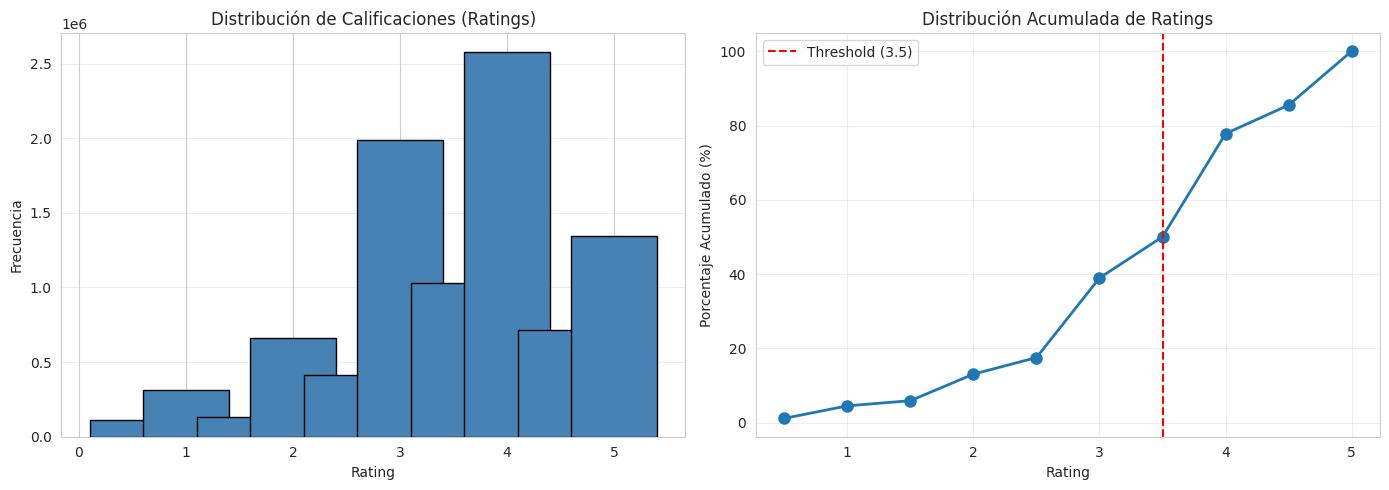

- La mayor concentración de ratings está en valores intermedios-altos, con sesgo hacia calificaciones positivas.
- El umbral 3.5 separa una zona de mayor preferencia, útil para binarizar likes/dislikes.

✓ Gráficas generadas


In [11]:
# Análisis de distribución de ratings
print("DISTRIBUCIÓN DE RATINGS ORIGINALES\n")

rating_distribution = ratings_dedupe.groupBy("rating").count().orderBy("rating").collect()
print("Distribución:")
for row in rating_distribution:
    print(f"  Rating {row['rating']}: {row['count']:,} ({100*row['count']/ratings_dedupe.count():.2f}%)")

# Estadísticas descriptivas
rating_stats = ratings_dedupe.select(
    count("*").alias("Total"),
    avg("rating").alias("Media"),
    stddev("rating").alias("Desv. Est."),
    min("rating").alias("Mínimo"),
    max("rating").alias("Máximo"),
    percentile_approx("rating", 0.25).alias("Q1"),
    percentile_approx("rating", 0.5).alias("Mediana"),
    percentile_approx("rating", 0.75).alias("Q3")
).collect()

print("\nESTADÍSTICAS DESCRIPTIVAS:")
for col_name in ["Total", "Media", "Desv. Est.", "Mínimo", "Máximo", "Q1", "Mediana", "Q3"]:
    val = rating_stats[0][col_name]
    print(f"  {col_name}: {val:.2f}")

# Convertir a pandas para graficar (usar DataFrame API en lugar de SQL)
rating_dist_pd = ratings_dedupe.groupBy("rating").count().orderBy("rating").toPandas()

# Crear gráfica de distribución
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].bar(rating_dist_pd['rating'], rating_dist_pd['count'], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Calificaciones (Ratings)')
axes[0].grid(axis='y', alpha=0.3)

# Distribución acumulada
rating_dist_pd['cumsum'] = rating_dist_pd['count'].cumsum()
rating_dist_pd['cumsum_pct'] = 100 * rating_dist_pd['cumsum'] / rating_dist_pd['count'].sum()
axes[1].plot(rating_dist_pd['rating'], rating_dist_pd['cumsum_pct'], marker='o', linewidth=2, markersize=8)
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Porcentaje Acumulado (%)')
axes[1].set_title('Distribución Acumulada de Ratings')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=RATING_THRESHOLD, color='red', linestyle='--', label=f'Threshold ({RATING_THRESHOLD})')
axes[1].legend()

plt.tight_layout()
plt.show()

print("- La mayor concentración de ratings está en valores intermedios-altos, con sesgo hacia calificaciones positivas.")
print(f"- El umbral {RATING_THRESHOLD} separa una zona de mayor preferencia, útil para binarizar likes/dislikes.")

print("\n✓ Gráficas generadas")

/tmp/ipykernel_61336/2480744502.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn')


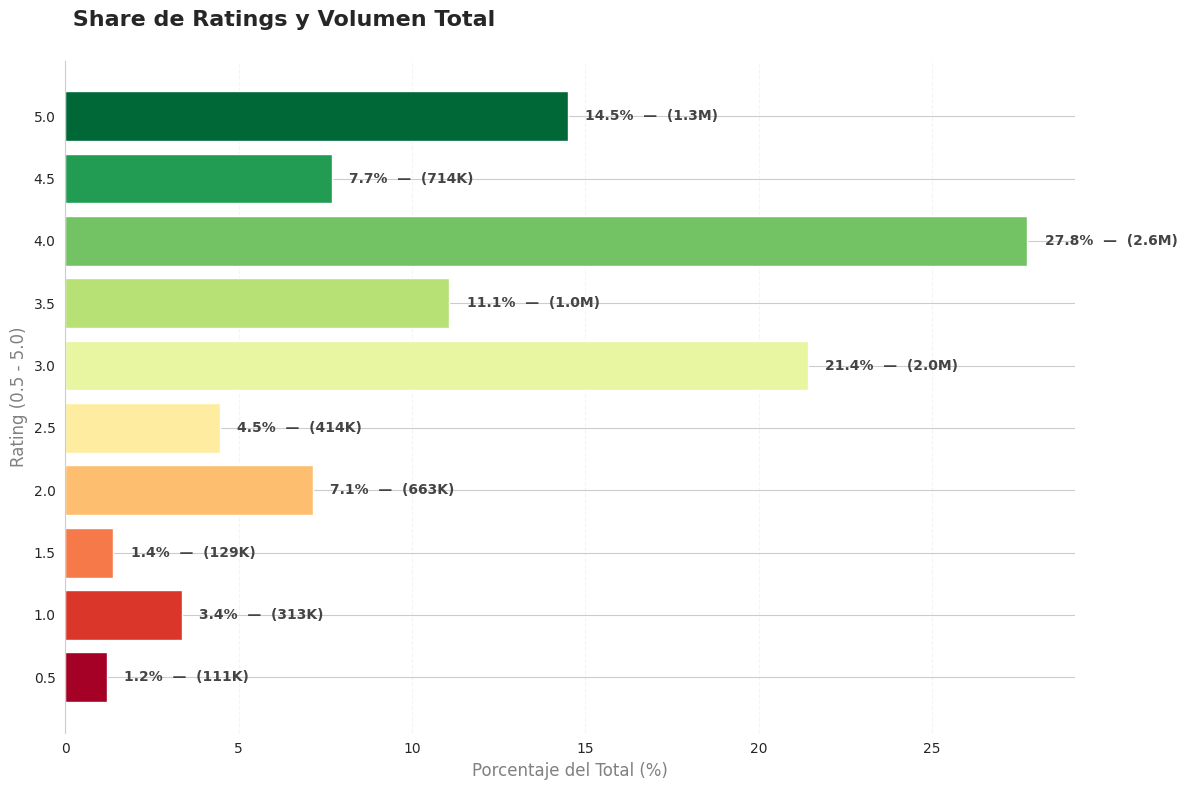

In [12]:


total_ratings = rating_dist_pd['count'].sum()
rating_dist_pd['share_pct'] = (rating_dist_pd['count'] / total_ratings) * 100

def format_fancy_label(x):
    if x >= 1_000_000: return f'{x/1_000_000:.1f}M'
    if x >= 1_000: return f'{x/1_000:.0f}K'
    return str(int(x))

fig, ax = plt.subplots(figsize=(12, 8))


cmap = plt.cm.get_cmap('RdYlGn')
norm = plt.Normalize(vmin=rating_dist_pd['rating'].min(), vmax=rating_dist_pd['rating'].max())
colors = [cmap(norm(value)) for value in rating_dist_pd['rating']]

bars = ax.barh(rating_dist_pd['rating'].astype(str),
               rating_dist_pd['share_pct'],
               color=colors,
               edgecolor='white',
               height=0.8)

for i, bar in enumerate(bars):
    width = bar.get_width()
    real_count = format_fancy_label(rating_dist_pd['count'].iloc[i])
    pct = rating_dist_pd['share_pct'].iloc[i]


    ax.text(width + 0.5,
            bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%  —  ({real_count})',
            va='center',
            fontsize=10,
            fontweight='bold',
            color='#444444')

ax.set_title(' Share de Ratings y Volumen Total', fontsize=16, fontweight='bold', pad=25, loc='left')
ax.set_xlabel('Porcentaje del Total (%)', fontsize=12, color='gray')
ax.set_ylabel('Rating (0.5 - 5.0)', fontsize=12, color='gray')


for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

ax.xaxis.grid(True, linestyle='--', alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Paso 2: Análisis de ratings por usuario

In [13]:
# Análisis de ratings por usuario
print("ANÁLISIS DE RATINGS POR USUARIO\n")

# Contar ratings por usuario
ratings_per_user = ratings_dedupe.groupBy("userId").agg(count("*").alias("num_ratings"))

# Estadísticas
user_stats = ratings_per_user.select(
    count("*").alias("Num_Usuarios"),
    avg("num_ratings").alias("Media_Ratings_Por_Usuario"),
    stddev("num_ratings").alias("Desv_Est"),
    min("num_ratings").alias("Min"),
    max("num_ratings").alias("Max"),
    percentile_approx("num_ratings", 0.5).alias("Mediana")
).collect()[0]

print(f"Número de usuarios: {int(user_stats['Num_Usuarios']):,}")
print(f"Media de ratings por usuario: {user_stats['Media_Ratings_Por_Usuario']:.2f}")
print(f"Desviación estándar: {user_stats['Desv_Est']:.2f}")
print(f"Mínimo: {int(user_stats['Min'])}")
print(f"Máximo: {int(user_stats['Max'])}")
print(f"Mediana: {int(user_stats['Mediana'])}")

# Top 10 usuarios más activos
print("\nTOP 10 USUARIOS MÁS ACTIVOS:")
top_users = ratings_per_user.orderBy(desc("num_ratings")).limit(10)
for row in top_users.collect():
    print(f"  Usuario {row['userId']}: {row['num_ratings']} ratings")

# Gráficas
ratings_per_user_pd = ratings_per_user.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de ratings por usuario
axes[0].hist(ratings_per_user_pd['num_ratings'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Número de ratings por usuario')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Actividad de Usuarios')
axes[0].set_yscale('log')
axes[0].grid(axis='y', alpha=0.3)

# Box plot
axes[1].boxplot(ratings_per_user_pd['num_ratings'], vert=True)
axes[1].set_ylabel('Número de ratings')
axes[1].set_title('Box Plot: Ratings por Usuario')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("- La actividad de usuarios es altamente desigual: pocos usuarios concentran muchos ratings y la mayoría participa poco.")
print("- La escala logarítmica y el boxplot evidencian una cola larga típica en sistemas de recomendación.")


ANÁLISIS DE RATINGS POR USUARIO

Número de usuarios: 64,191
Media de ratings por usuario: 144.68
Desviación estándar: 228.47
Mínimo: 20
Máximo: 7515
Mediana: 68

TOP 10 USUARIOS MÁS ACTIVOS:


ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt
ERROR:py4j.clientserver:Exception occurred while shutting down connection
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver

KeyboardInterrupt: 

### Paso 3: Análisis de ratings por película

In [14]:
# Análisis de ratings por película
print("ANÁLISIS DE RATINGS POR PELÍCULA\n")

# Unir ratings con información de películas
ratings_with_movie = ratings_dedupe.join(
    movies_dedupe.select("movieId", "title"),
    on="movieId",
    how="inner"
)

# Contar ratings por película
ratings_per_movie = ratings_dedupe.groupBy("movieId").agg(
    count("*").alias("num_ratings"),
    avg("rating").alias("avg_rating")
).join(
    movies_dedupe.select("movieId", "title"),
    on="movieId",
    how="inner"
)

# Estadísticas
movie_stats = ratings_per_movie.select(
    count("*").alias("Num_Películas"),
    avg("num_ratings").alias("Media_Ratings"),
    stddev("num_ratings").alias("Desv_Est"),
    min("num_ratings").alias("Min"),
    max("num_ratings").alias("Max"),
    percentile_approx("num_ratings", 0.5).alias("Mediana")
).collect()[0]

print(f"Número de películas: {int(movie_stats['Num_Películas']):,}")
print(f"Media de ratings por película: {movie_stats['Media_Ratings']:.2f}")
print(f"Desviación estándar: {movie_stats['Desv_Est']:.2f}")
print(f"Mínimo: {int(movie_stats['Min'])}")
print(f"Máximo: {int(movie_stats['Max'])}")
print(f"Mediana: {int(movie_stats['Mediana'])}")

# TOP 10 películas más calificadas
print("\nTOP 10 PELÍCULAS MÁS CALIFICADAS:")
top_movies = ratings_per_movie.orderBy(desc("num_ratings")).limit(10)
for row in top_movies.collect():
    print(f"  {row['title']}: {row['num_ratings']} ratings (avg: {row['avg_rating']:.2f})")

# Películas menos calificadas
print("\nTOP 10 PELÍCULAS MENOS CALIFICADAS:")
least_movies = ratings_per_movie.orderBy("num_ratings").limit(10)
for row in least_movies.collect():
    print(f"  {row['title']}: {row['num_ratings']} ratings")

# Gráficas
ratings_per_movie_pd = ratings_per_movie.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de ratings por película
axes[0].hist(ratings_per_movie_pd['num_ratings'], bins=50, color='seagreen', edgecolor='black')
axes[0].set_xlabel('Número de ratings por película')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Popularidad de Películas')
axes[0].set_yscale('log')
axes[0].grid(axis='y', alpha=0.3)

# Scatter: num_ratings vs avg_rating
axes[1].scatter(ratings_per_movie_pd['num_ratings'],
                ratings_per_movie_pd['avg_rating'],
                alpha=0.5, s=20)
axes[1].set_xlabel('Número de ratings')
axes[1].set_ylabel('Rating promedio')
axes[1].set_title('Popularidad vs Calificación Promedio')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("- La popularidad también sigue cola larga: pocas películas concentran gran parte de los ratings.")
print("- No se observa una relación lineal fuerte entre popularidad y rating promedio; hay películas populares con promedio moderado.")


ANÁLISIS DE RATINGS POR PELÍCULA



ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt
ERROR:py4j.clientserver:Exception occurred while shutting down connection
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver

KeyboardInterrupt: 

### Paso 4: Análisis de géneros

---

# PARTE II: PROCESAMIENTO DISTRIBUIDO CON SPARK

## Introducción a la Parte II

En esta sección demostramos el poder del procesamiento distribuido con Spark para operaciones sobre datos masivos:

1. **Contar ratings:** Por película y por usuario usando operaciones distribuidas
2. **Ranking de popularidad:** Identificar las películas más calificadas (top 20)
3. **Comparativa de rendimiento:** RDDs vs DataFrames/Spark SQL
4. **Visualización:** Presentar resultados en tablas y gráficas

---

## Paso 1: Contar ratings por película y usuario (DataFrames)

In [15]:
# Contar ratings por película usando DataFrames
print("CONTEO DISTRIBUIDO CON SPARK DATAFRAMES\n")

# Método 1: DataFrames/Spark SQL (Recomendado para grandes volúmenes)
print("Método 1: Spark SQL (Optimizado para datasets masivos)")
print("-" * 60)

start_time = time.time()

# Crear tabla temporal
ratings_dedupe.createOrReplaceTempView("ratings_temp")
movies_dedupe.createOrReplaceTempView("movies_temp")

# Contar ratings por película usando SQL
top_movies_sql = spark.sql("""
    SELECT
        m.movieId,
        m.title,
        m.genres,
        COUNT(r.rating) as num_ratings,
        ROUND(AVG(r.rating), 2) as avg_rating
    FROM ratings_temp r
    JOIN movies_temp m ON r.movieId = m.movieId
    GROUP BY m.movieId, m.title, m.genres
    ORDER BY num_ratings DESC
    LIMIT 20
""")

dataframe_time = time.time() - start_time

print(f"\nTop 20 películas por número de ratings (Spark SQL):\n")
top_movies_sql.show(20, truncate=False)
print(f"Tiempo de ejecución: {dataframe_time:.4f} segundos\n")

# Guardar resultados para comparación posterior
top_movies_sql_results = top_movies_sql.collect()

CONTEO DISTRIBUIDO CON SPARK DATAFRAMES

Método 1: Spark SQL (Optimizado para datasets masivos)
------------------------------------------------------------

Top 20 películas por número de ratings (Spark SQL):



ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

## Paso 2: Comparativa RDDs vs DataFrames/Spark SQL

In [16]:
# Método 2: RDDs (Estilo MapReduce - más bajo nivel)
print("\nMétodo 2: RDDs (MapReduce tradicional)")
print("-" * 60)

start_time = time.time()

# Convertir a RDD
ratings_rdd = ratings_dedupe.rdd

# Extraer (movieId, 1) para cada rating
movie_ratings_rdd = ratings_rdd.map(lambda x: (x['movieId'], 1))

# Contar ratings por película usando reduceByKey (MapReduce)
movie_counts_rdd = movie_ratings_rdd.reduceByKey(lambda a, b: a + b)

# Ordenar por count descendente y obtener top 20
top_20_rdd = movie_counts_rdd.top(20, key=lambda x: x[1])

rdd_time = time.time() - start_time

print(f"\nTop 20 películas por número de ratings (RDD):")
print("movieId | num_ratings")
print("-" * 30)
for movie_id, count in top_20_rdd:
    print(f"{movie_id:<7} | {count}")
print(f"\nTiempo de ejecución: {rdd_time:.4f} segundos")

# Comparativa
print("\n" + "=" * 60)
print("COMPARATIVA DE RENDIMIENTO")
print("=" * 60)
print(f"DataFrames/Spark SQL: {dataframe_time:.4f} segundos")
print(f"RDDs (MapReduce):     {rdd_time:.4f} segundos")
print(f"Speedup (SQL/RDD):    {rdd_time/dataframe_time:.2f}x")
print("\nConclusión:")
print("→ Spark SQL es más eficiente gracias al query optimizer")
print("→ RDDs son más flexibles pero requieren más optimización manual")
print("→ Para operaciones analíticas estándar: usar DataFrames/SQL")


Método 2: RDDs (MapReduce tradicional)
------------------------------------------------------------


ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

In [ ]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
from collections import Counter

# =========================
# Rangos de rating
# =========================
rangos = [
    ("Rating < 1", "avg_rating < 1"),
    ("1 <= Rating < 2", "avg_rating >= 1 AND avg_rating < 2"),
    ("2 <= Rating < 3.5", "avg_rating >= 2 AND avg_rating < 3.5"),
    ("3.5 <= Rating < 4", "avg_rating >= 3.5 AND avg_rating < 4"),
    ("4 <= Rating <= 5", "avg_rating >= 4 AND avg_rating <= 5")
]

# =========================
# Figura
# =========================
fig, axes = plt.subplots(5, 1, figsize=(14, 28))
plt.subplots_adjust(hspace=0.7)

# =========================
# Loop por rangos
# =========================
for i, (titulo_rango, condicion) in enumerate(rangos):

    # Filtrar top películas
    df_rango_spark = (
        top_movies_sql
        .filter(condicion)
        .orderBy(F.desc("num_ratings"))
        .limit(10)
    )

    # Convertir a pandas
    df_plot = df_rango_spark.toPandas()

    if not df_plot.empty:

        # Acortar títulos
        df_plot['title_short'] = df_plot['title'].str[:45]

        # =====================================
        # Género dominante
        # =====================================
        all_genres = []

        for genres in df_plot['genres']:
            all_genres.extend(str(genres).split('|'))

        genre_counter = Counter(all_genres)
        genero_dominante = genre_counter.most_common(1)[0][0]

        # =====================================
        # Barras horizontales
        # =====================================
        bars = axes[i].barh(
            range(len(df_plot)),
            df_plot['num_ratings'],
            color='steelblue',
            edgecolor='black',
            height=0.7
        )

        # =====================================
        # Configuración gráfica
        # =====================================
        axes[i].set_title(
            f'Top 10 Películas: {titulo_rango} | Género dominante: {genero_dominante}',
            fontsize=15,
            fontweight='bold'
        )

        axes[i].set_xlabel(
            'Número de ratings',
            fontsize=12
        )

        # Ocultar eje Y
        axes[i].set_yticks([])

        axes[i].invert_yaxis()

        axes[i].grid(axis='x', alpha=0.3)

        # Reducir espacio vacío derecha
        max_value = df_plot['num_ratings'].max()
        axes[i].set_xlim(0, max_value * 1.12)

        # =====================================
        # Texto dentro barras
        # =====================================
        for idx, (bar, title, value) in enumerate(
            zip(bars, df_plot['title_short'], df_plot['num_ratings'])
        ):

            # Nombre película
            axes[i].text(
                value * 0.03,
                bar.get_y() + bar.get_height()/2,
                title,
                va='center',
                ha='left',
                fontsize=11,
                color='white',
                fontweight='bold'
            )

            # Valor numérico
            axes[i].text(
                value + (max_value * 0.01),
                bar.get_y() + bar.get_height()/2,
                f'{int(value):,}',
                va='center',
                fontsize=10,
                fontweight='bold'
            )

    else:

        axes[i].text(
            0.5,
            0.5,
            f'Sin datos para el rango: {titulo_rango}',
            ha='center',
            va='center',
            fontsize=12,
            color='gray'
        )

        axes[i].set_title(
            f'Top 10 Películas: {titulo_rango}',
            fontsize=12,
            fontweight='bold'
        )

# =========================
# Mostrar gráfico
# =========================
plt.tight_layout()
plt.show()

print("✓ Gráficos horizontales optimizados generados")

In [17]:
# Crear representación: cada película = conjunto de usuarios con rating positivo (binary_rating = 1)
print("CREANDO REPRESENTACIÓN POR USUARIOS\n")
print("=" * 70)

# Filtrar solo ratings positivos (like = 1)
positive_ratings = ratings_binary.filter(col("binary_rating") == 1)

# Agrupar usuarios por película
movies_users = positive_ratings.groupBy("movieId").agg(
    collect_list("userId").alias("user_set")
).join(
    movies_dedupe.select("movieId", "title"),
    on="movieId",
    how="inner"
)

# Mostrar ejemplos
print("Representación: Cada película como conjunto de usuarios que la calificaron positivamente\n")
print("Ejemplos:")
example_movies = movies_users.limit(5).collect()
for row in example_movies:
    user_list = sorted(row['user_set'])[:10]  # Mostrar solo los primeros 10
    print(f"\nMovieId: {row['movieId']}")
    print(f"Title: {row['title']}")
    print(f"Usuarios (primeros 10): {user_list}")
    print(f"Total de usuarios: {len(row['user_set'])}")

# Guardar como tabla para usar después
movies_users.createOrReplaceTempView("movies_users_view")

print(f"\n✓ Se crearon {movies_users.count()} representaciones de películas")

CREANDO REPRESENTACIÓN POR USUARIOS

Representación: Cada película como conjunto de usuarios que la calificaron positivamente

Ejemplos:

MovieId: 31
Title: Dangerous Minds (1995)
Usuarios (primeros 10): [29, 42, 57, 60, 61, 127, 209, 279, 294, 298]
Total de usuarios: 1858

MovieId: 53
Title: Lamerica (1994)
Usuarios (primeros 10): [1638, 3515, 5234, 5508, 8405, 9485, 9511, 12767, 13285, 14705]
Total de usuarios: 42

MovieId: 65
Title: Bio-Dome (1996)
Usuarios (primeros 10): [204, 251, 422, 768, 850, 1099, 1281, 1505, 1539, 1540]
Total de usuarios: 430

MovieId: 78
Title: Crossing Guard, The (1995)
Usuarios (primeros 10): [114, 184, 675, 959, 1365, 1983, 2983, 3471, 3625, 3673]
Total de usuarios: 183

MovieId: 85
Title: Angels and Insects (1995)
Usuarios (primeros 10): [41, 208, 310, 324, 375, 443, 603, 685, 717, 741]
Total de usuarios: 706

✓ Se crearon 19710 representaciones de películas


# PARTE IV. REGLAS DE ASOCIACIÓN Y CONJUNTOS FRECUENTES

En esta sección aplicamos el algoritmo **FP-Growth** distribuido mediante Spark MLlib para descubrir patrones interesantes en las calificaciones de películas. El objetivo es identificar reglas de asociación que revelen relaciones entre películas: si los usuarios que califican positivamente una película tienden a calificar positivamente otra.

## Metodología
- **Datos**: Transacciones de usuarios con películas con calificación positiva (≥ 3.5 sobre 5)
- **Algoritmo**: FP-Growth (Frequent Pattern Growth) implementado en Spark
- **Métricas de evaluación**:
  - **Soporte**: Proporción de transacciones que contienen ambos items
  - **Confianza**: P(consecuente | antecedente)
  - **Lift**: Razón entre confianza observada y confianza esperada independientemente

In [18]:
from pyspark.sql.functions import col, collect_list, size

print("\n" + "="*70)
print("ANÁLISIS DE PÉRDIDA DE USUARIOS")
print("="*70 + "\n")

# ==============================
# 1. Usuarios originales
# ==============================
total_users = ratings.select("userId").distinct().count()
print(f"Usuarios totales originales: {total_users:,}")

# ==============================
# 2. Usuarios con rating positivo
# ==============================
positive_ratings = ratings.filter(col("rating") >= 3.5)

users_positive = positive_ratings.select("userId").distinct().count()
print(f"Usuarios con ratings positivos: {users_positive:,}")
print(f"Usuarios perdidos aquí: {total_users - users_positive:,}")

# ==============================
# 3. Construir transacciones
# ==============================
transactions = positive_ratings.groupBy("userId").agg(
    collect_list(col("movieId")).alias("movies")
)

users_transactions = transactions.count()
print(f"\nUsuarios con transacciones: {users_transactions:,}")

# ==============================
# 4. Filtrar size > 1
# ==============================
filtered_min = transactions.filter(size(col("movies")) > 1)

users_min = filtered_min.count()
print(f"\nUsuarios con >1 película: {users_min:,}")
print(f"Usuarios eliminados (size <=1): {users_transactions - users_min:,}")

# ==============================
# 5. Filtrar size <= 50
# ==============================
filtered_max = filtered_min.filter(size(col("movies")) <= 220)

users_final = filtered_max.count()
print(f"\nUsuarios finales (<=50 películas): {users_final:,}")
print(f"Usuarios eliminados (size >50): {users_min - users_final:,}")

# ==============================
# 6. Resumen total
# ==============================
total_lost = total_users - users_final

print("\n" + "-"*70)
print("RESUMEN FINAL")
print("-"*70)
print(f"Usuarios iniciales: {total_users:,}")
print(f"Usuarios finales: {users_final:,}")
print(f"Total perdidos: {total_lost:,}")
print(f"Porcentaje perdido: {(total_lost / total_users)*100:.2f}%")


ANÁLISIS DE PÉRDIDA DE USUARIOS

Usuarios totales originales: 64,191
Usuarios con ratings positivos: 64,135
Usuarios perdidos aquí: 56

Usuarios con transacciones: 64,135

Usuarios con >1 película: 64,084
Usuarios eliminados (size <=1): 51

Usuarios finales (<=50 películas): 58,096
Usuarios eliminados (size >50): 5,988

----------------------------------------------------------------------
RESUMEN FINAL
----------------------------------------------------------------------
Usuarios iniciales: 64,191
Usuarios finales: 58,096
Total perdidos: 6,095
Porcentaje perdido: 9.50%


In [ ]:
from pyspark.ml.fpm import FPGrowth
from pyspark.sql.functions import col, collect_list, size, slice

print("\n" + "="*70)
print("FP-GROWTH OPTIMIZADO (ANTI-OOM)")
print("="*70 + "\n")

# ==============================
# 1. Parámetros SEGUROS
# ==============================
RATING_THRESHOLD = 3.5
MIN_SUPPORT = 0.03
MIN_CONFIDENCE = 0.1

# ==============================
# 2. Preparar transacciones
# ==============================
positive_movies_per_user = ratings.filter(
    col('rating') >= RATING_THRESHOLD
).groupBy('userId').agg(
    collect_list(col('movieId')).alias('movies')
)

#FILTROS CRÍTICOS
positive_movies_per_user = positive_movies_per_user \
    .filter(size(col("movies")) > 1) \
    .filter(size(col("movies")) <= 220)   # evitar usuarios extremos

print(f"Transacciones: {positive_movies_per_user.count()}")

# ==============================
# 3. FP-Growth
# ==============================
fp = FPGrowth(
    itemsCol="movies",
    minSupport=MIN_SUPPORT,
    minConfidence=MIN_CONFIDENCE,
    numPartitions=4
)

model = fp.fit(positive_movies_per_user)

# ==============================
# 4. ITEMSETS (sin explotar RAM)
# ==============================
print("\nTop Itemsets Frecuentes:")
model.freqItemsets.limit(10).show(truncate=False)

# ==============================
# 5. REGLAS (sin orderBy global)
# ==============================
rules = model.associationRules

print("\nReglas (muestra):")
rules.limit(10).show(truncate=False)

# ==============================
# 6. LIFT (seguro)
# ==============================
from pyspark.sql.functions import explode

total_transactions = positive_movies_per_user.count()

# soporte de items individuales
item_support = model.freqItemsets \
    .filter(size(col("items")) == 1) \
    .withColumn("item", col("items")[0]) \
    .withColumn("support_item", col("freq") / total_transactions) \
    .select("item", "support_item")

# calcular lift sin explotar memoria
rules_with_lift = rules \
    .withColumn("consequent_item", explode(col("consequent"))) \
    .join(item_support, col("consequent_item") == col("item"), "left") \
    .withColumn("lift", col("confidence") / col("support_item"))

print("\nReglas con LIFT (muestra):")
rules_with_lift.select(
    "antecedent", "consequent", "confidence", "lift"
).limit(10).show(truncate=False)


FP-GROWTH OPTIMIZADO (ANTI-OOM)

Transacciones: 58096

Top Itemsets Frecuentes:
+--------------------+-----+
|items               |freq |
+--------------------+-----+
|[318]               |22345|
|[260]               |16763|
|[260, 318]          |7480 |
|[260, 296]          |7484 |
|[260, 296, 318]     |4821 |
|[260, 593]          |7341 |
|[260, 593, 318]     |4788 |
|[260, 593, 296]     |4916 |
|[260, 593, 296, 318]|3520 |
|[260, 356]          |6743 |
+--------------------+-----+


Reglas (muestra):


In [ ]:
from pyspark.sql.functions import col, explode, size

print("\n" + "="*70)
print("TOP 10 REGLAS RELEVANTES (con métricas)")
print("="*70 + "\n")

# ==============================
# 1. Calcular soporte real
# ==============================
total_transactions = positive_movies_per_user.count()

rules_enriched = rules_with_lift.withColumn(
    "support",
    col("confidence") * col("support_item")  # aproximación válida
)

# ==============================
# 2. Filtrar reglas relevantes
# ==============================
rules_filtered = rules_enriched.filter(
    (col("confidence") >= 0.2) &   # más estrictas
    (col("lift") > 1)              # asociación positiva real
)

# ==============================
# 3. Top 10 por LIFT (sin order global pesado)
# ==============================
top_rules = rules_filtered.sortWithinPartitions(
    col("lift").desc()
).limit(10)

# ==============================
# 4. Mostrar resultados
# ==============================
top_rules.select(
    "antecedent",
    "consequent",
    "support",
    "confidence",
    "lift"
).show(truncate=False)

In [ ]:
from difflib import SequenceMatcher
from pyspark.sql.functions import col
import builtins

# Función auxiliar para calcular similitud (0 a 1)
def string_similarity(a, b):
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()

print("\n" + "="*70)
print("PASO 4: DETALLES DE LAS REGLAS RELEVANTES (FILTRANDO SECUELAS)")
print("="*70)

# ==============================
# 1. Convertir reglas a lista (un poco más de 10 para tener margen tras filtrar)
# ==============================
top_rules_list = rules_filtered.sortWithinPartitions(col("lift").desc()).limit(50).collect()

# ==============================
# 2. Diccionario movieId → title (ya lo tienes)
# ==============================
movie_dict = {
    int(row["movieId"]): row["title"]
    for row in movies.select("movieId", "title").collect()
}

# ==============================
# 3. Mostrar reglas filtrando similitud > 90%
# ==============================
rules_shown = 0
MAX_RULES_TO_DISPLAY = 10
SIMILARITY_THRESHOLD = 0.85 # 85-90% suele detectar secuelas (Toy Story 1 vs Toy Story 2)

for row in top_rules_list:
    if rules_shown >= MAX_RULES_TO_DISPLAY:
        break

    antecedent_ids = row["antecedent"]
    consequent_ids = row["consequent"]

    # Obtener títulos
    antecedent_titles = [movie_dict.get(int(i), f"ID:{i}") for i in antecedent_ids]
    consequent_titles = [movie_dict.get(int(i), f"ID:{i}") for i in consequent_ids]

    # --- LÓGICA DE FILTRADO DE SIMILITUD ---
    is_too_similar = False
    for a_title in antecedent_titles:
        for c_title in consequent_titles:
            # Si el título es 90% igual, lo marcamos como secuela/obvio
            if string_similarity(a_title, c_title) > SIMILARITY_THRESHOLD:
                is_too_similar = True
                break
        if is_too_similar: break

    if is_too_similar:
        continue # Saltamos esta regla y vamos a la siguiente
    # ---------------------------------------

    rules_shown += 1
    print(f"\n╔═ REGLA {rules_shown} ═{'='*65}")
    print(f"║")
    print(f"║   SI usuario calificó positivamente:")
    for title in antecedent_titles:
        print(f"║      → {title}")
    print(f"║")
    print(f"║   ENTONCES es probable que también calificó positivamente:")
    for title in consequent_titles:
        print(f"║      → {title}")
    print(f"║")
    print(f"║   Métricas:")
    print(f"║      • Soporte:   {row['support']:.4f}")
    print(f"║      • Confianza: {row['confidence']:.4f}")
    print(f"║      • Lift:      {row['lift']:.4f}x")

    # Interpretación rápida
    strength = "MUY FUERTE" if row['lift'] > 1.5 else "FUERTE"
    print(f"║      • Fuerza:    {strength}")
    print(f"╚{'='*71}")

if rules_shown == 0:
    print("No se encontraron reglas que superen los filtros de relevancia y diversidad.")

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from difflib import SequenceMatcher
from pyspark.sql.functions import col

# 1. Función de similitud (definirla aquí asegura que exista)
def string_similarity(a, b):
    return SequenceMatcher(None, str(a).lower(), str(b).lower()).ratio()

# 2. Aseguramos que rules_filtered exista y tenga los datos frescos
# Usamos rules_enriched que ya definiste en tu query anterior
rules_filtered = rules_enriched.filter(
    (col("confidence") >= 0.2) &
    (col("lift") > 1.2)  # Subimos un poco el lift para mejores asociaciones
)

# 3. Recolectamos un poco más de 10 para tener margen tras el filtro de similitud
# .collect() es seguro aquí porque solo traemos 30 filas a la memoria local
raw_top_rules = rules_filtered.sortWithinPartitions(col("lift").desc()).limit(30).collect()

# 4. Construcción del Grafo
G = nx.DiGraph()
SIMILARITY_THRESHOLD = 0.85
rules_added = 0

for row in raw_top_rules:
    if rules_added >= 10: break # Límite estricto pedido

    u_id, v_id = row["antecedent"][0], row["consequent"][0]
    u_title = movie_dict.get(int(u_id), f"ID:{u_id}")
    v_title = movie_dict.get(int(v_id), f"ID:{v_id}")

    if string_similarity(u_title, v_title) < SIMILARITY_THRESHOLD:
        G.add_edge(u_title, v_title, weight=row["lift"])
        rules_added += 1

# 5. Renderizado del Grafo
plt.figure(figsize=(14, 9))
pos = nx.spring_layout(G, k=1.2, seed=42) # k controla la distancia entre nodos

# Dibujamos nodos
nx.draw_networkx_nodes(G, pos, node_size=3500, node_color='#5dade2',
                       edgecolors='white', linewidths=2, alpha=0.9)

# Dibujamos flechas (curvas para que se vea Pro)
nx.draw_networkx_edges(G, pos, width=2, edge_color='#abb2b9',
                       arrowsize=20, connectionstyle='arc3,rad=0.15')

# Dibujamos etiquetas
nx.draw_networkx_labels(G, pos, font_size=10, font_family='sans-serif', font_weight='bold')

# Etiquetas de Lift en las flechas
edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}x" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9, font_color='red')

plt.title("Grafo de Recomendaciones: Top 10 Asociaciones No Obvias",
          fontsize=15, fontweight='bold', pad=20)
plt.axis('off')
plt.show()

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from difflib import SequenceMatcher
from pyspark.sql.functions import col

# ==========================================
# 1. Funciones Auxiliares Mejoradas
# ==========================================

def string_similarity(a, b):
    """Calcula similitud de texto."""
    return SequenceMatcher(None, str(a).lower(), str(b).lower()).ratio()

def get_short_title(title, max_chars=25):
    """
    Recorta títulos largos y añade saltos de línea.
    'The Lord of the Rings: The Fellowship...' -> 'Lord of the...\nRings: Fellowship'
    """
    title = str(title).replace(" (", "\n(").split(" (")[0] # Elimina año si está entre paréntesis
    if len(title) > max_chars:
        # Intenta cortar en el primer espacio después de la mitad
        split_pos = title.find(' ', len(title)//2)
        if split_pos != -1:
            title = title[:split_pos] + '\n' + title[split_pos+1:]
        else:
            title = title[:max_chars-3] + "..."
    return title

# ==========================================
# 2. Preparación de Datos (Igual que antes)
# ==========================================
try:
    # Aseguramos que rules_filtered exista
    rules_filtered = rules_enriched.filter(
        (col("confidence") >= 0.2) &
        (col("lift") > 1.2)
    )
    # Recolectamos 30 para tener margen
    raw_top_rules = rules_filtered.sortWithinPartitions(col("lift").desc()).limit(30).collect()
except NameError:
    print("Error: Asegúrate de ejecutar la celda que define 'rules_enriched' y 'movie_dict' antes.")
    raw_top_rules = []

# ==========================================
# 3. Construcción del Grafo Optimizada
# ==========================================
G = nx.DiGraph()
SIMILARITY_THRESHOLD = 0.85
rules_added = 0

for row in raw_top_rules:
    if rules_added >= 10: break

    u_id, v_id = row["antecedent"][0], row["consequent"][0]

    # Obtenemos títulos originales
    u_title_orig = movie_dict.get(int(u_id), f"ID:{u_id}")
    v_title_orig = movie_dict.get(int(v_id), f"ID:{v_id}")

    # Filtro de similitud sobre títulos originales
    if string_similarity(u_title_orig, v_title_orig) < SIMILARITY_THRESHOLD:
        # --- APLICAMOS FORMATEO DE TÍTULOS AQUÍ ---
        u_title_formatted = get_short_title(u_title_orig)
        v_title_formatted = get_short_title(v_title_orig)
        # ------------------------------------------

        # Añadimos la conexión usando títulos formateados como IDs de nodo
        G.add_edge(u_title_formatted, v_title_formatted, weight=row["lift"])
        rules_added += 1

# ==========================================
# 4. Renderizado Anticolisión
# ==========================================
plt.figure(figsize=(16, 11)) # Aumentamos el tamaño del lienzo

# Layout Spring con fuerte repulsión (k=2.5 o superior)
# k=2.5 es el "resorte" que separa nodos; iterations=100 estabiliza.
pos = nx.spring_layout(G, k=2.8, iterations=100, seed=42)

# --- Dibujar Nodos (Más pequeños) ---
nx.draw_networkx_nodes(G, pos,
                       node_size=2800, # Reducimos tamaño (antes 3500)
                       node_color='#3498db',
                       edgecolors='white',
                       linewidths=2,
                       alpha=0.85)

# --- Dibujar Flechas (Estilizadas) ---
nx.draw_networkx_edges(G, pos,
                       width=1.5,
                       edge_color='#bdc3c7',
                       arrowsize=20,
                       connectionstyle='arc3,rad=0.18', # Un poco más curva
                       alpha=0.6)

# --- Dibujar Etiquetas de Títulos (Fuente más pequeña y ajustada) ---
nx.draw_networkx_labels(G, pos,
                        font_size=9, # Un punto menos
                        font_family='sans-serif',
                        font_weight='bold',
                        # Ajuste fino: subimos el texto para que no pise la flecha
                        verticalalignment='center')

# --- Etiquetas de Lift sobre las flechas (Opcional, pero ayuda) ---
edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}x" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                             font_size=8, font_color='#e74c3c', label_pos=0.6)

plt.title("Grafo de Recomendaciones: Top 10 Asociaciones (Distribución Ajustada)",
          fontsize=16, fontweight='bold', pad=25)
plt.axis('off') # Ocultar ejes
plt.tight_layout()
plt.show()

In [ ]:
from pyspark.sql.functions import col
import builtins

print("\n" + "="*70)
print("PASO 4: DETALLES DE LAS REGLAS PRINCIPALES")
print("="*70)

# ==============================
# 1. Convertir reglas a lista (seguro)
# ==============================
top_rules_list = top_rules.collect()  # solo 10 → OK

# ==============================
# 2. Diccionario movieId → title
# ==============================
movie_dict = {
    int(row["movieId"]): row["title"]
    for row in movies.select("movieId", "title").collect()
}

# ==============================
# 3. Mostrar reglas (bonito)
# ==============================
for idx, row in enumerate(top_rules_list[:5], 1):
    antecedent_ids = row["antecedent"]
    consequent_ids = row["consequent"]

    # Convertir IDs → títulos
    antecedent_titles = [movie_dict.get(int(i), f"ID:{i}") for i in antecedent_ids]
    consequent_titles = [movie_dict.get(int(i), f"ID:{i}") for i in consequent_ids]

    print(f"\n╔═ REGLA {idx} ═{'='*65}")
    print(f"║")
    print(f"║  SI usuario calificó positivamente:")
    for title in antecedent_titles:
        print(f"║    → {title}")
    print(f"║")
    print(f"║  ENTONCES es probable que también calificó positivamente:")
    for title in consequent_titles:
        print(f"║    → {title}")
    print(f"║")
    print(f"║  Métricas:")
    print(f"║    • Soporte:   {row['support']:.4f} ({row['support']*100:.2f}%)")
    print(f"║    • Confianza: {row['confidence']:.4f} ({row['confidence']*100:.2f}%)")
    print(f"║    • Lift:      {row['lift']:.4f}x")

    # Interpretación del lift
    if row['lift'] > 1.5:
        strength = "MUY FUERTE"
    elif row['lift'] > 1.2:
        strength = "FUERTE"
    elif row['lift'] > 1.0:
        strength = "MODERADA"
    else:
        strength = "DÉBIL"

    print(f"║    • Fuerza:    {strength}")
    print(f"╚{'='*71}")

# ==============================
# 4. Estadísticas generales (seguro)
# ==============================
print(f"\n{'='*70}")
print("ESTADÍSTICAS GENERALES DE REGLAS")
print("="*70)

# 🔥 IMPORTANTE: limitar para no romper memoria
all_rules = rules_with_lift.select(
    "support", "confidence", "lift"
).limit(1000).collect()

if all_rules:
    confidences = [float(r["confidence"]) for r in all_rules]
    lifts = [float(r["lift"]) for r in all_rules]
    supports = [float(r["support"]) for r in all_rules]

    print(f"Total de reglas analizadas: {len(all_rules)}")

    print(f"\nConfianza:")
    print(f"  Media:    {builtins.sum(confidences)/len(confidences):.4f}")
    print(f"  Mínima:   {builtins.min(confidences):.4f}")
    print(f"  Máxima:   {builtins.max(confidences):.4f}")

    print(f"\nLift:")
    print(f"  Media:    {builtins.sum(lifts)/len(lifts):.4f}")
    print(f"  Mínimo:   {builtins.min(lifts):.4f}")
    print(f"  Máximo:   {builtins.max(lifts):.4f}")

    print(f"\nSoporte:")
    print(f"  Media:    {builtins.sum(supports)/len(supports):.6f}")
    print(f"  Mínimo:   {builtins.min(supports):.6f}")
    print(f"  Máximo:   {builtins.max(supports):.6f}")
else:
    print("No hay reglas para mostrar")

print(f"\n{'='*70}\n")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import builtins

if top_rules_list:

    # ==============================
    # 1. Preparar datos
    # ==============================
    top_n = builtins.min(10, len(top_rules_list))

    rule_labels = []
    confidence_vals = []
    lift_vals = []
    support_vals = []

    for row in top_rules_list[:top_n]:
        antecedent_ids = row["antecedent"]
        consequent_ids = row["consequent"]

        # Convertir a títulos (solo el primero para etiqueta)
        ant_title = movie_dict.get(int(antecedent_ids[0]), str(antecedent_ids[0]))
        cons_title = movie_dict.get(int(consequent_ids[0]), str(consequent_ids[0]))

        rule_labels.append(f"{ant_title[:20]}\n→ {cons_title[:20]}")

        confidence_vals.append(float(row["confidence"]))
        lift_vals.append(float(row["lift"]))
        support_vals.append(float(row["support"]))

    # ==============================
    # 2. Crear gráficos
    # ==============================
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Análisis de Reglas de Asociación (FP-Growth)', fontsize=14, fontweight='bold')

    x_pos = np.arange(len(rule_labels))

    # 🔹 Confianza
    axes[0].bar(x_pos, confidence_vals)
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(range(1, len(rule_labels) + 1))
    axes[0].set_ylabel('Confianza')
    axes[0].set_title('Confianza')
    axes[0].set_ylim([0, 1.05])

    for i, v in enumerate(confidence_vals):
        axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center')

    # 🔹 Lift
    axes[1].bar(x_pos, lift_vals)
    axes[1].axhline(y=1.0, linestyle='--')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(range(1, len(rule_labels) + 1))
    axes[1].set_ylabel('Lift')
    axes[1].set_title('Lift')

    for i, v in enumerate(lift_vals):
        axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center')

    # 🔹 Soporte
    axes[2].bar(x_pos, support_vals)
    axes[2].set_xticks(x_pos)
    axes[2].set_xticklabels(range(1, len(rule_labels) + 1))
    axes[2].set_ylabel('Soporte')
    axes[2].set_title('Soporte')

    for i, v in enumerate(support_vals):
        axes[2].text(i, v + 0.0005, f'{v:.4f}', ha='center')

    plt.tight_layout()
    plt.show()